# Week 3 Day 4
Today, we'll finish up the data visualization introduction with a libary called `networkx`. 

In [2]:
# preliminaries

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

### NetworkX
`networkx` is a popular network drawing Python library. The foundational object in the library is the `graph` object. This object stores nodes and edges with the option of more data.

To create a `graph` in `networkx`, we can use the `nx.Graph()` function:

In [3]:
contgraph = nx.Graph()
type(contgraph)

networkx.classes.graph.Graph

Now that we have a `graph`, let's investigate whatever information might be stored in the object. Since we have only <i>made</i> the graph and not adding any nodes or edges, these lists are empty:

In [4]:
contgraph.edges()

EdgeView([])

In [5]:
contgraph.nodes()

NodeView(())

We can add some nodes and edges:

In [6]:
contgraph.add_node('A') # create node with name 'A'
contgraph.add_node(1) # create node with name 1

In [7]:
contgraph.add_edge('A', 1)

Great! Now, we have a graph with two nodes ('A' and 1) and a single edge ( { 'A' , 1 } ). To see the graph, we can visualize it with `nx.draw()`:

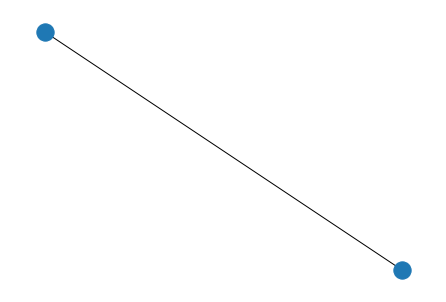

In [8]:
nx.draw(contgraph)

We can't tell which node is which. But, `networkx` saves the label information so we can tell `networkx` to display that:

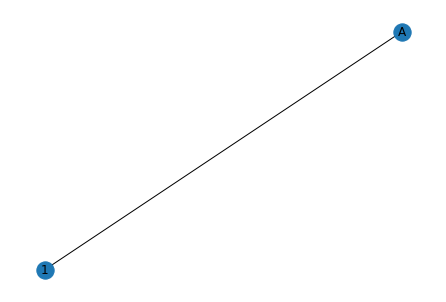

In [9]:
nx.draw(contgraph,
       with_labels=True)

Like the `matplotlib` library, we can control lots of features in the graphs as well. You can try these for yourself in lab:

Text(0.5, 1.0, 'Example Graph 1')

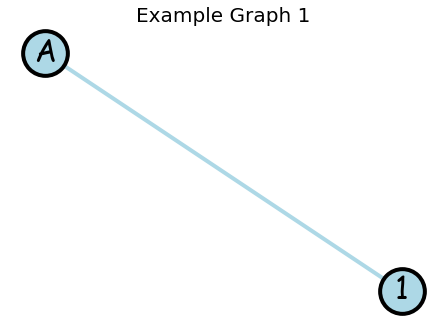

In [10]:
nx.draw(contgraph,
       with_labels = True,       # creates node labels
       node_size = 2000,         # controls node size
       node_color = 'lightblue', # controls color within the node
       edge_color = 'lightblue', # controls color within the edge
       width = 4,                # controls width of edges
       edgecolors = 'black',     # color of node boundary
       linewidths = 4,           # width of node boundary
       font_size=30,             # node label size
       font_family='cursive')    # node label font   

plt.title('Example Graph 1',
         fontsize=20)

Instead of forcing these features for all nodes, you can make them individual with lists as well:

Text(0.5, 1.0, 'Example Graph 2')

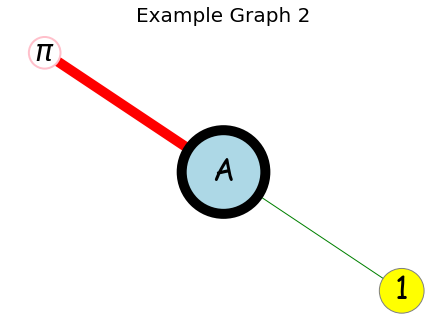

In [11]:
contgraph2 = nx.Graph()
contgraph2.add_edges_from([ ('A', 1), ('A', '$\pi$')])

nx.draw(contgraph2,
       with_labels = True,       
       node_size = [7000, 2000, 1000],         
       node_color = ['lightblue', 'yellow', 'white'],
       edge_color = ['green', 'red'],
       width = [1,10],                
       edgecolors = ['black', 'grey', 'pink'],     
       linewidths = [10, 1, 2],           
       font_size =30,             
       font_family='cursive')     

plt.title('Example Graph 2',
         fontsize=20)

## Networks from Data

Networks are particularly useful for visualizing data. Using `pandas`, we can visualize some fun network data.

In the "Datasets" folder on GitHub, there is a `csv` file entitled "DolpinNetwork.csv". This `csv` file contains the social information of a dolphin community written about in this paper: https://abdn.elsevierpure.com/en/publications/the-bottlenose-dolphin-community-of-doubtful-sound-features-a-lar/ .

In [12]:
dolphincsv = pd.read_csv("DolphinNetwork.csv")

In [13]:
dolphincsv

,Source,Target
0,Double,CCL
1,Feather,DN16
2,Feather,DN21
3,Fish,Beak
4,Fish,Bumper
...,...,...
154,Zap,Topless
155,Zig,Ripplefluke
156,Zipfel,Bumper
157,Zipfel,SN4


Each dolphin is a "source" or "target" if the dolphins communicate/touch/hangout often. The dolphins will be nodes and their friendship/non-friendship will be indicated with edges.  

First, let's convert these into tuples:

In [14]:
edges = [(dolphincsv['Source'].iloc[i], dolphincsv['Target'].iloc[i]) for i in range(len(dolphincsv))]

In [15]:
edges

[('Double', 'CCL'),
 ('Feather', 'DN16'),
 ('Feather', 'DN21'),
 ('Fish', 'Beak'),
 ('Fish', 'Bumper'),
 ('Gallatin', 'DN16'),
 ('Gallatin', 'DN21'),
 ('Gallatin', 'Feather'),
 ('Grin', 'Beak'),
 ('Grin', 'CCL'),
 ('Haecksel', 'Beak'),
 ('Hook', 'Grin'),
 ('Jet', 'Beescratch'),
 ('Jet', 'DN21'),
 ('Jet', 'Feather'),
 ('Jet', 'Gallatin'),
 ('Jonah', 'Haecksel'),
 ('Knit', 'Beescratch'),
 ('Knit', 'DN63'),
 ('Kringel', 'Double'),
 ('Kringel', 'Hook'),
 ('Kringel', 'Jonah'),
 ('MN105', 'Jonah'),
 ('MN23', 'Jet'),
 ('MN83', 'Grin'),
 ('MN83', 'Haecksel'),
 ('MN83', 'Jonah'),
 ('Mus', 'Jet'),
 ('Notch', 'Beescratch'),
 ('Notch', 'Mus'),
 ('Number1', 'Beescratch'),
 ('Number1', 'DN63'),
 ('Number1', 'Jet'),
 ('Number1', 'Mus'),
 ('Number1', 'Notch'),
 ('Oscar', 'Beescratch'),
 ('Oscar', 'Double'),
 ('Oscar', 'Kringel'),
 ('Patchback', 'Fish'),
 ('Patchback', 'Jonah'),
 ('Patchback', 'MN105'),
 ('Patchback', 'MN83'),
 ('PL', 'DN63'),
 ('PL', 'Knit'),
 ('PL', 'Oscar'),
 ('Quasi', 'Jet'),
 ('Ri

We now have a list of edges. Let's create a graph to put the edges in:

In [16]:
dolphin = nx.Graph()
dolphin.add_edges_from(edges) # add all the edges at once

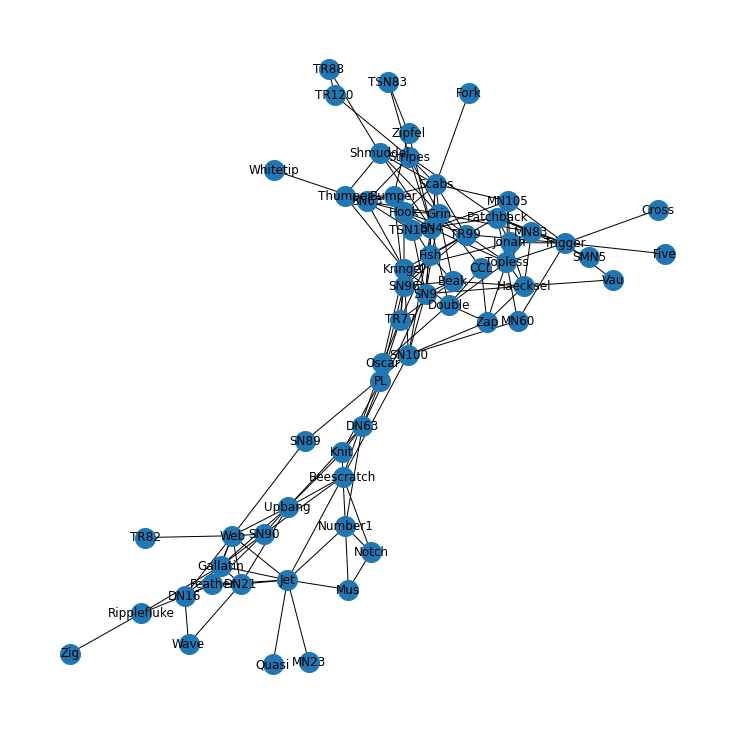

In [17]:
plt.figure(figsize = (10,10))

nx.draw(dolphin,
       node_size=400,
       with_labels=True)

This will be the network you will deal with today in lab.